### Setup e data ingestion

In [1]:
!pip install micromlgen

  Preparing metadata (setup.py) ... done
  Created wheel for micromlgen: filename=micromlgen-1.1.28-py3-none-any.whl size=32152 sha256=e432f881f35bbafd68eb407d85cef19048f5ff397e9a9e94120976bac1e4c7cc
  Stored in directory: /root/.cache/pip/wheels/16/02/8a/3a8b533174e4f7691a8fd72dab4493fb6819b79f8fcc1d18a6
Successfully built micromlgen


In [3]:
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from micromlgen import port

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Esecuzione in locale (fuori da Colab).")

BASE_DIR = "/content/drive/MyDrive/har-iot-project"
DATA_DIR = os.path.join(BASE_DIR, "data", "raw", "PAMAP2_Dataset", "Protocol")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

ACTIVITY_NAMES = {
    1: "Lying (Sdraiato)",
    2: "Sitting (Seduto)",
    3: "Standing (In piedi)",
    4: "Walking (Camminata)",
    5: "Running (Corsa)",
    6: "Cycling (Bici)",
    7: "Nordic Walk",
    12: "Stairs Up (Salire le scale)",
    13: "Stairs Down (Scendere le scale)",
    16: "Vacuuming (Passare l'aspirapolvere)",
    17: "Ironing (Stirare)"
}

SMARTWATCH_COLS = [
    "timestamp", "activity_id", "heart_rate",
    "hand_temp",
    "hand_acc_16g_x", "hand_acc_16g_y", "hand_acc_16g_z",
    "hand_gyro_x", "hand_gyro_y", "hand_gyro_z"
]

ALL_COLS = ["timestamp", "activity_id", "heart_rate"] + \
           [f"hand_{c}" for c in ["temp", "acc_16g_x", "acc_16g_y", "acc_16g_z", "acc_6g_x", "acc_6g_y", "acc_6g_z", "gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z", "ori_1", "ori_2", "ori_3", "ori_4"]] + \
           [f"chest_{c}" for c in ["temp", "acc_16g_x", "acc_16g_y", "acc_16g_z", "acc_6g_x", "acc_6g_y", "acc_6g_z", "gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z", "ori_1", "ori_2", "ori_3", "ori_4"]] + \
           [f"ankle_{c}" for c in ["temp", "acc_16g_x", "acc_16g_y", "acc_16g_z", "acc_6g_x", "acc_6g_y", "acc_6g_z", "gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z", "ori_1", "ori_2", "ori_3", "ori_4"]]

def load_smartwatch_data(subject_id: int):
    path = os.path.join(DATA_DIR, f"subject10{subject_id}.dat")
    try:
        df = pd.read_csv(path, sep=r'\s+', header=None, names=ALL_COLS, na_values="NaN")
        df = df[SMARTWATCH_COLS].copy()
        df["subject_id"] = subject_id
        return df
    except FileNotFoundError:
        return pd.DataFrame()

print("Caricamento dati in corso...")
df_raw = pd.concat([load_smartwatch_data(s) for s in range(1, 10)], ignore_index=True)
print(f"Dati caricati. Shape: {df_raw.shape}")

Mounted at /content/drive
Caricamento dati in corso...
Dati caricati. Shape: (2872533, 11)


### Preprocessing e downsampling

In [6]:
df = df_raw[df_raw["activity_id"] > 0].copy()

df.interpolate(method="linear", inplace=True)
df.bfill(inplace=True)
df.ffill(inplace=True)

FS_ORIG, FS_TARGET = 100.0, 33.3
def apply_filter(signal, cutoff=20.0, fs=100.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype="low", analog=False)
    return filtfilt(b, a, signal)

print("Applicazione filtro passa-basso sulle accelerazioni...")
acc_cols = [c for c in df.columns if "acc" in c]
for col in acc_cols:
    df[col] = apply_filter(df[col].values)

print("Sottocampionamento dei dati (100Hz -> 33Hz)...")
mask = df.groupby("subject_id").cumcount() % 3 == 0
df_ds = df[mask].reset_index(drop=True)

df_ds["t_ds"] = df_ds.groupby("subject_id").cumcount()
print(f"Downsampling completato. Nuova shape: {df_ds.shape}")

Applicazione filtro passa-basso sulle accelerazioni...
Sottocampionamento dei dati (100Hz -> 33Hz)...
Downsampling completato. Nuova shape: (647627, 12)


### Windowing e Subject-Independent split

In [7]:
FEATURE_COLS = [c for c in df_ds.columns if c not in ["subject_id", "t_ds", "activity_id", "timestamp"]]
TEMP_IDX = FEATURE_COLS.index("hand_temp")

WINDOW_SIZE = int(4.0 * FS_TARGET)
STEP_SIZE = int(2.0 * FS_TARGET)

def create_windows_fast(df_subj):
    data = df_subj.sort_values("t_ds").reset_index(drop=True)
    X_vals = data[FEATURE_COLS].values
    y_vals = data["activity_id"].values

    X, y = [], []
    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE
        labels, counts = np.unique(y_vals[start:end], return_counts=True)
        X.append(X_vals[start:end])
        y.append(labels[np.argmax(counts)])

    return np.array(X), np.array(y)

X_seq_list, y_list, subj_list = [], [], []

print("Creazione finestre temporali...")
for sid in df_ds['subject_id'].unique():
    X_s, y_s = create_windows_fast(df_ds[df_ds["subject_id"] == sid])
    if len(X_s) > 0:
        X_seq_list.append(X_s)
        y_list.append(y_s)
        subj_list.append(np.full(len(y_s), sid))

X_all = np.concatenate(X_seq_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
subj_all = np.concatenate(subj_list, axis=0)

labels_unique = np.sort(np.unique(y_all)).astype(int)
label_to_idx = {lab: i for i, lab in enumerate(labels_unique)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}
y_all_idx = np.vectorize(label_to_idx.get)(y_all)

train_mask = np.isin(subj_all, [1, 2, 3, 4, 5, 6, 7])
test_mask  = np.isin(subj_all, [8, 9])

X_train_seq, y_train = X_all[train_mask], y_all_idx[train_mask]
X_test_seq, y_test   = X_all[test_mask], y_all_idx[test_mask]

print(f"Finestre estratte. Train X: {X_train_seq.shape}, Test X: {X_test_seq.shape}")

Creazione finestre temporali...
Finestre estratte. Train X: (8446, 133, 8), Test X: (1353, 133, 8)


### Feature Extraction & ML

In [9]:
def extract_features(X_seq):
    return np.concatenate([
        X_seq.mean(axis=1), X_seq.std(axis=1),
        X_seq.min(axis=1), X_seq.max(axis=1)
    ], axis=1)

X_train_feat = extract_features(X_train_seq)
X_test_feat  = extract_features(X_test_seq)

num_base_feats = len(FEATURE_COLS)
temp_cols_to_remove = [TEMP_IDX, TEMP_IDX + num_base_feats, TEMP_IDX + 2*num_base_feats, TEMP_IDX + 3*num_base_feats]

X_train_feat_notemp = np.delete(X_train_feat, temp_cols_to_remove, axis=1)
X_test_feat_notemp  = np.delete(X_test_feat, temp_cols_to_remove, axis=1)

print("Addestramento Modello EDGE BASE (RF Leggero - ESP32)...")
rf_edge = RandomForestClassifier(n_estimators=15, max_depth=8, n_jobs=-1, random_state=42)
rf_edge.fit(X_train_feat_notemp, y_train)
acc_rf_edge = accuracy_score(y_test, rf_edge.predict(X_test_feat_notemp))

print("Addestramento Modello FOG BASE (RF Pesante)...")
rf_fog = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_fog.fit(X_train_feat_notemp, y_train)
acc_rf_fog = accuracy_score(y_test, rf_fog.predict(X_test_feat_notemp))

print("Addestramento Modello FOG CONTEXT (RF Pesante)...")
rf_fog_context = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_fog_context.fit(X_train_feat, y_train)
acc_rf_fog_context = accuracy_score(y_test, rf_fog_context.predict(X_test_feat))

xgb_params = {
    'n_estimators': 150,
    'max_depth': 6,
    'learning_rate': 0.1,
    'objective': 'multi:softmax',
    'num_class': len(labels_unique),
    'n_jobs': -1,
    'random_state': 42
}

print("Addestramento Modello XGBoost BASE...")
xgb_notemp = XGBClassifier(**xgb_params)
xgb_notemp.fit(X_train_feat_notemp, y_train)
acc_xgb_notemp = accuracy_score(y_test, xgb_notemp.predict(X_test_feat_notemp))

print("Addestramento Modello XGBoost CONTEXT...")
xgb_context = XGBClassifier(**xgb_params)
xgb_context.fit(X_train_feat, y_train)
acc_xgb_context = accuracy_score(y_test, xgb_context.predict(X_test_feat))

Addestramento Modello EDGE BASE (RF Leggero - ESP32)...
Addestramento Modello FOG BASE (RF Pesante)...
Addestramento Modello FOG CONTEXT (RF Pesante)...
Addestramento Modello XGBoost BASE...
Addestramento Modello XGBoost CONTEXT...


### Risultati

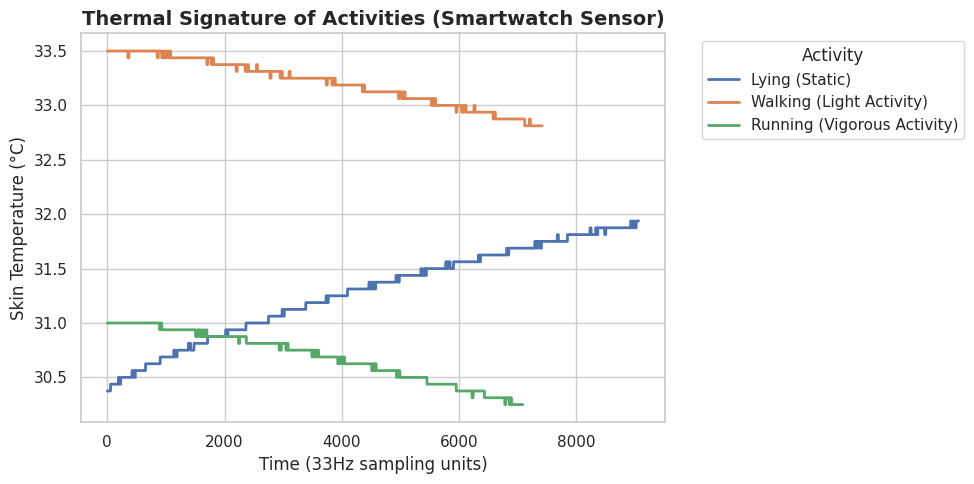

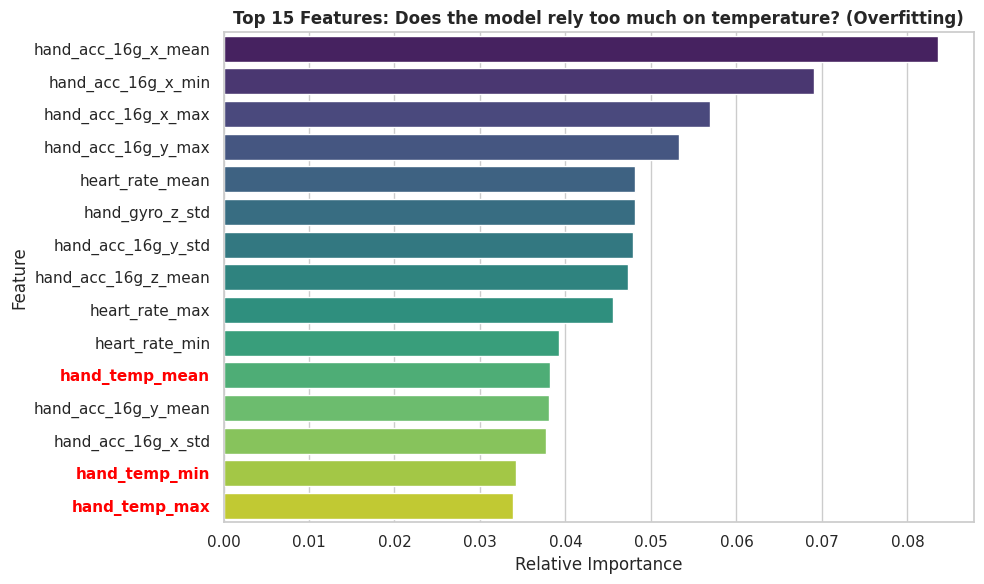

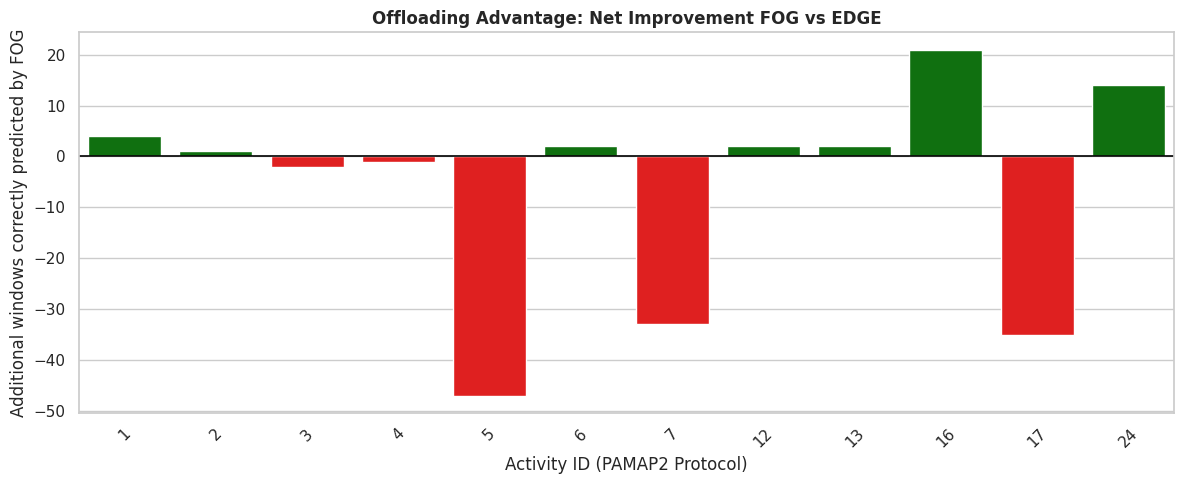

In [11]:
sns.set_theme(style="whitegrid")

results_df = pd.DataFrame({
    "Ambiente": ["Edge", "Fog", "Fog", "Fog", "Fog"],
    "Modello": ["RF Leggero (Base)", "RF Pesante (Base)", "RF Pesante (Context)", "XGBoost (Base)", "XGBoost (Context)"],
    "Accuracy (%)": [acc_rf_edge*100, acc_rf_fog*100, acc_rf_fog_context*100, acc_xgb_notemp*100, acc_xgb_context*100]
})

with open(os.path.join(RESULTS_DIR, "accuracy_results.md"), "w") as f:
    f.write("=== RISULTATI ARCHITETTURA EDGE-FOG ===\n")
    f.write(results_df.to_markdown(index=False))

plt.figure(figsize=(10, 5))
sample_subject = df_ds[df_ds["subject_id"] == 1].copy()
plot_labels = {1: "Lying (Static)", 4: "Walking (Light Activity)", 5: "Running (Vigorous Activity)"}

for act_id, act_name in plot_labels.items():
    subset = sample_subject[sample_subject["activity_id"] == act_id]
    if not subset.empty:
        t_zeroed = subset["t_ds"] - subset["t_ds"].min()
        sns.lineplot(x=t_zeroed, y=subset["hand_temp"], label=act_name, linewidth=2)

plt.title("Thermal Signature of Activities (Smartwatch Sensor)", fontsize=14, fontweight='bold')
plt.xlabel("Time (33Hz sampling units)", fontsize=12)
plt.ylabel("Skin Temperature (°C)", fontsize=12)
plt.legend(title="Activity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "firma_termica.png"), dpi=300, bbox_inches='tight')
plt.show()

stat_names = ['mean', 'std', 'min', 'max']
feat_names_full = [f"{col}_{stat}" for stat in stat_names for col in FEATURE_COLS]
importances = rf_fog_context.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15
top_features = [feat_names_full[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, hue=top_features, palette="viridis", legend=False)
plt.title("Top 15 Features: Does the model rely too much on temperature? (Overfitting)", fontweight='bold')
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
for i, label in enumerate(plt.gca().get_yticklabels()):
    if "temp" in label.get_text():
        label.set_color("red")
        label.set_fontweight("bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_importance_context.png"), dpi=300, bbox_inches='tight')
plt.show()

all_classes = np.arange(len(labels_unique))
cm_fog = confusion_matrix(y_test, rf_fog.predict(X_test_feat_notemp), labels=all_classes)
cm_edge = confusion_matrix(y_test, rf_edge.predict(X_test_feat_notemp), labels=all_classes)
cm_diff = cm_fog - cm_edge
correct_diff = np.diag(cm_diff)
class_labels = [idx_to_label[i] for i in range(len(labels_unique))]

plt.figure(figsize=(12, 5))
colors = ['green' if val > 0 else 'red' if val < 0 else 'grey' for val in correct_diff]
sns.barplot(x=class_labels, y=correct_diff, hue=class_labels, palette=colors, legend=False)
plt.title("Offloading Advantage: Net Improvement FOG vs EDGE", fontweight='bold')
plt.xlabel("Activity ID (PAMAP2 Protocol)")
plt.ylabel("Additional windows correctly predicted by FOG")
plt.axhline(0, color='black', linewidth=1.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "delta_confusion_matrix_fog_vs_edge.png"), dpi=300, bbox_inches='tight')
plt.show()

### Macro-fatigue

Scansione dell'intero dataset per trovare l'hardware più affidabile...
-> Trovata la migliore combinazione nel dataset: 'Walking (Camminata)' (Soggetto 7) con 11240 campioni validi!


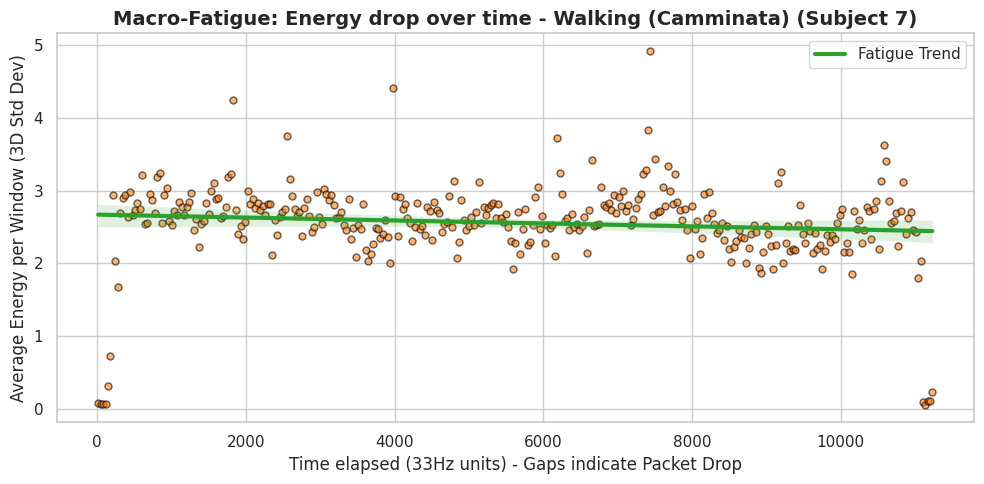


Esecuzione test Machine Learning (Fase Iniziale vs Fase Finale)...
-> Accuratezza Modello nel distinguere Fase Iniziale da Fase Finale: 97.06%
-> CONCLUSIONE: L'algoritmo riconosce chiaramente quando l'utente è stanco. Serve un sistema Edge adattivo!


In [12]:
cardio_ids = [4, 5, 6, 7, 12, 13] # Camminata, Corsa, Bici, Nordic, Scale

print("Scansione dell'intero dataset per trovare l'hardware più affidabile...")

best_combo = None
max_valid_samples = 0

for subj in df_ds["subject_id"].unique():
    subj_data = df_ds[df_ds["subject_id"] == subj]
    for act_id in cardio_ids:
        valid_count = len(subj_data[subj_data["activity_id"] == act_id].dropna(subset=["hand_acc_16g_x"]))
        if valid_count > max_valid_samples:
            max_valid_samples = valid_count
            best_combo = (subj, act_id)

if best_combo is not None and max_valid_samples > 500:
    TARGET_SUBJECT, TARGET_ACTIVITY = best_combo
    act_name = ACTIVITY_NAMES.get(TARGET_ACTIVITY, f"ID {TARGET_ACTIVITY}")

    print(f"-> Trovata la migliore combinazione nel dataset: '{act_name}' (Soggetto {TARGET_SUBJECT}) con {max_valid_samples} campioni validi!")

    act_data = df_ds[(df_ds["subject_id"] == TARGET_SUBJECT) & (df_ds["activity_id"] == TARGET_ACTIVITY)].copy()
    act_data = act_data.dropna(subset=["hand_acc_16g_x", "hand_acc_16g_y", "hand_acc_16g_z"]).copy()

    act_data["acc_mag_3d"] = np.sqrt(act_data["hand_acc_16g_x"]**2 + act_data["hand_acc_16g_y"]**2 + act_data["hand_acc_16g_z"]**2)
    act_data["t_session"] = act_data["t_ds"] - act_data["t_ds"].min()

    window_size = 33
    windows = [group for _, group in act_data.groupby(np.arange(len(act_data)) // window_size)]

    t_points, energy_points = [], []

    for w in windows:
        if len(w) > 5:
            t_points.append(w["t_session"].mean())
            energy_points.append(w["acc_mag_3d"].std())

    fatigue_df = pd.DataFrame({"t_session": t_points, "acc_energy": energy_points}).dropna()

    if len(fatigue_df) > 10:
        plt.figure(figsize=(10, 5))
        sns.regplot(x="t_session", y="acc_energy", data=fatigue_df,
                    scatter_kws={'alpha':0.6, 's':25, 'color':'#ff7f0e', 'edgecolor':'black'},
                    line_kws={'color':'#2ca02c', 'linewidth':3, 'label':'Fatigue Trend'})

        plt.title(f"Macro-Fatigue: Energy drop over time - {act_name} (Subject {TARGET_SUBJECT})", fontsize=14, fontweight='bold')
        plt.xlabel("Time elapsed (33Hz units) - Gaps indicate Packet Drop", fontsize=12)
        plt.ylabel("Average Energy per Window (3D Std Dev)", fontsize=12)
        plt.legend()
        plt.tight_layout()

        plt.savefig(os.path.join(RESULTS_DIR, "fatigue_drift.png"), dpi=300, bbox_inches='tight')
        plt.show()

        midpoint = fatigue_df["t_session"].median()
        print("\nEsecuzione test Machine Learning (Fase Iniziale vs Fase Finale)...")

        MINI_WINDOW, MINI_STEP = int(4.0 * FS_TARGET), int(2.0 * FS_TARGET)
        X_fatigue, y_fatigue = [], []

        X_vals = act_data[FEATURE_COLS].values
        y_vals = (act_data["t_session"] > midpoint).astype(int).values

        for start in range(0, len(act_data) - MINI_WINDOW + 1, MINI_STEP):
            end = start + MINI_WINDOW
            labels, counts = np.unique(y_vals[start:end], return_counts=True)
            X_fatigue.append(X_vals[start:end])
            y_fatigue.append(labels[np.argmax(counts)])

        X_fatigue, y_fatigue = np.array(X_fatigue), np.array(y_fatigue)

        if len(X_fatigue) > 10:
            X_fat_feat = extract_features(X_fatigue)
            X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_fat_feat, y_fatigue, test_size=0.2, random_state=42)

            rf_fatigue = RandomForestClassifier(n_estimators=50, random_state=42)
            rf_fatigue.fit(X_f_train, y_f_train)
            acc_fatigue = accuracy_score(y_f_test, rf_fatigue.predict(X_f_test))

            print(f"-> Accuratezza Modello nel distinguere Fase Iniziale da Fase Finale: {acc_fatigue*100:.2f}%")
            if acc_fatigue > 0.65:
                print("-> CONCLUSIONE: L'algoritmo riconosce chiaramente quando l'utente è stanco. Serve un sistema Edge adattivo!")
            else:
                print("-> CONCLUSIONE: Il pattern cinematico non è cambiato significativamente.")
        else:
            print("Non ci sono abbastanza finestre valide per il ML.")
    else:
        print("Poche finestre calcolabili per il grafico.")
else:
    print("Errore critico: Il dataset PAMAP2 sembra non contenere dati validi per i sensori della mano.")

### Simulazione packet loss

Simulazione interferenze di rete in corso...
-> Drop Rate 0%: Edge Acc = 75.4%, Fog Acc = 70.1%
-> Drop Rate 5%: Edge Acc = 75.0%, Fog Acc = 70.3%
-> Drop Rate 10%: Edge Acc = 75.2%, Fog Acc = 70.0%
-> Drop Rate 20%: Edge Acc = 75.1%, Fog Acc = 70.2%
-> Drop Rate 30%: Edge Acc = 74.9%, Fog Acc = 70.5%
-> Drop Rate 40%: Edge Acc = 74.4%, Fog Acc = 70.7%
-> Drop Rate 50%: Edge Acc = 73.8%, Fog Acc = 70.1%


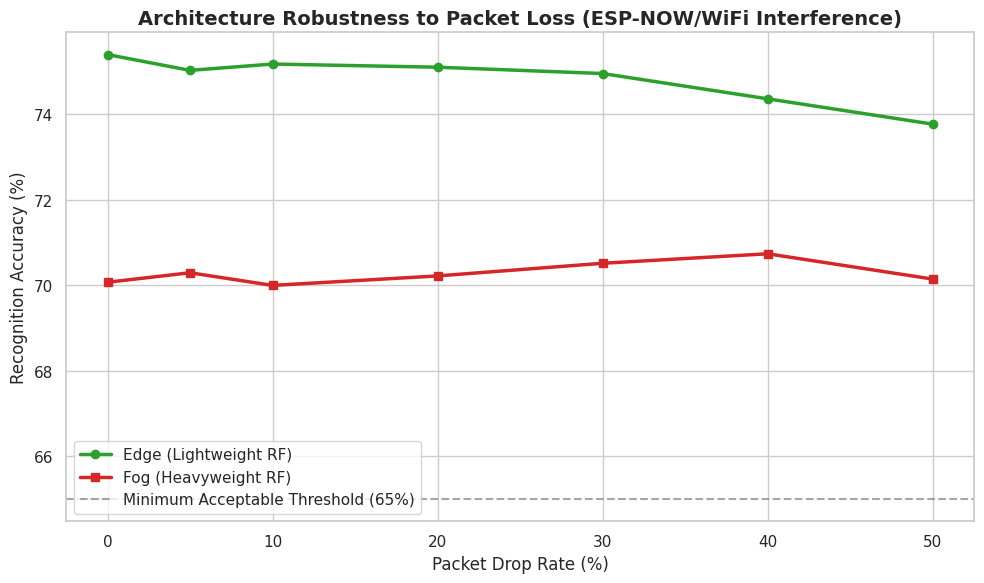

Grafico Packet Loss salvato in: /content/drive/MyDrive/har-iot-project/results/packet_loss_robustness.png


In [13]:
def simulate_packet_loss_and_extract(X_seq, drop_rate):

    X_corrupted = X_seq.copy()

    mask = np.random.rand(*X_corrupted.shape[:2]) < drop_rate

    for i in range(X_corrupted.shape[2]):
        X_corrupted[mask, i] = np.nan

    df_temp = pd.DataFrame(X_corrupted.reshape(-1, X_corrupted.shape[2]))
    df_temp.ffill(inplace=True)
    df_temp.bfill(inplace=True)

    X_reconstructed = df_temp.values.reshape(X_corrupted.shape)

    return extract_features(X_reconstructed)

drop_rates = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

acc_edge_loss = []
acc_fog_loss = []

print("Simulazione interferenze di rete in corso...")

for rate in drop_rates:
    X_feat_corrupted = simulate_packet_loss_and_extract(X_test_seq, rate)

    X_feat_corrupted_notemp = np.delete(X_feat_corrupted, temp_cols_to_remove, axis=1)

    acc_edge = accuracy_score(y_test, rf_edge.predict(X_feat_corrupted_notemp))
    acc_fog = accuracy_score(y_test, rf_fog.predict(X_feat_corrupted_notemp))

    acc_edge_loss.append(acc_edge * 100)
    acc_fog_loss.append(acc_fog * 100)
    print(f"-> Drop Rate {int(rate*100)}%: Edge Acc = {acc_edge*100:.1f}%, Fog Acc = {acc_fog*100:.1f}%")

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot([r*100 for r in drop_rates], acc_edge_loss, marker='o', label='Edge (Lightweight RF)', linewidth=2.5, color='#2ca02c')
plt.plot([r*100 for r in drop_rates], acc_fog_loss, marker='s', label='Fog (Heavyweight RF)', linewidth=2.5, color='#d62728')

plt.axhline(y=65, color='gray', linestyle='--', alpha=0.7, label='Minimum Acceptable Threshold (65%)')

plt.title("Architecture Robustness to Packet Loss (ESP-NOW/WiFi Interference)", fontsize=14, fontweight='bold')
plt.xlabel("Packet Drop Rate (%)", fontsize=12)
plt.ylabel("Recognition Accuracy (%)", fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()

loss_plot_path = os.path.join(RESULTS_DIR, "packet_loss_robustness.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafico Packet Loss salvato in: {loss_plot_path}")

### Export modelli + payload

In [ ]:
c_code = port(rf_edge)
model_path = os.path.join(RESULTS_DIR, "rf_model.h")
with open(model_path, "w") as f:
    f.write(c_code)
print(f"Modello EDGE salvato in: {model_path}")

TARGET_ACTIVITY_ID = 6
NUM_WINDOWS = 10
target_internal_idx = label_to_idx.get(TARGET_ACTIVITY_ID)

if target_internal_idx is not None:
    valid_indices = np.where(y_test == target_internal_idx)[0]
    if len(valid_indices) > 0:
        selected_indices = [valid_indices[i % len(valid_indices)] for i in range(NUM_WINDOWS)]
        simulated_stream = X_test_feat_notemp[selected_indices]
        activity_name = ACTIVITY_NAMES.get(TARGET_ACTIVITY_ID, f"Attività {TARGET_ACTIVITY_ID}")

        c_code_sim = "#ifndef PAYLOAD\n"
        c_code_sim += "#define PAYLOAD\n\n"

        c_code_sim += f"// --- FLUSSO DATI SIMULATO: {activity_name} ---\n"
        c_code_sim += f"const int NUM_WINDOWS = {NUM_WINDOWS};\n\n"

        c_code_sim += f"const float payload_data[{NUM_WINDOWS}][28] = {{\n"

        for i, window in enumerate(simulated_stream):
            row_str = "    {" + ", ".join([str(round(val, 5)) for val in window]) + "}"
            if i < NUM_WINDOWS - 1: row_str += ","
            c_code_sim += row_str + f" // Finestra {i+1} (Label ID: {TARGET_ACTIVITY_ID})\n"

        c_code_sim += "};\n\n"
        c_code_sim += "#endif\n"

        payload_sim_path = os.path.join(RESULTS_DIR, "payload.h")
        with open(payload_sim_path, "w") as f:
            f.write(c_code_sim)
        print(f"Payload salvato in: {payload_sim_path}")

model_path_pkl = os.path.join(RESULTS_DIR, "xgb_fog.pkl")
joblib.dump(xgb_notemp, model_path_pkl)
print(f"Modello Fog (XGBoost, Base) salvato in: {model_path_pkl}")

Modello EDGE salvato in: /content/drive/MyDrive/har-iot-project/results/rf_model.h
Payload salvato in: /content/drive/MyDrive/har-iot-project/results/payload.h
Modello Fog (XGBoost, Base) salvato in: /content/drive/MyDrive/har-iot-project/results/xgb_fog.pkl
